# *ASSIGNMENT-1: Find the communities*

In [23]:
import networkx as nx
import pandas as pd
from pathlib import Path
import community as community_louvain
import time
import random
from itertools import combinations
import igraph as ig
import leidenalg
from networkx.algorithms.community import girvan_newman
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [24]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [25]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [26]:
G = build_graph(filtered=df)
print(G.number_of_nodes())
print(G.number_of_edges())

3579
780393


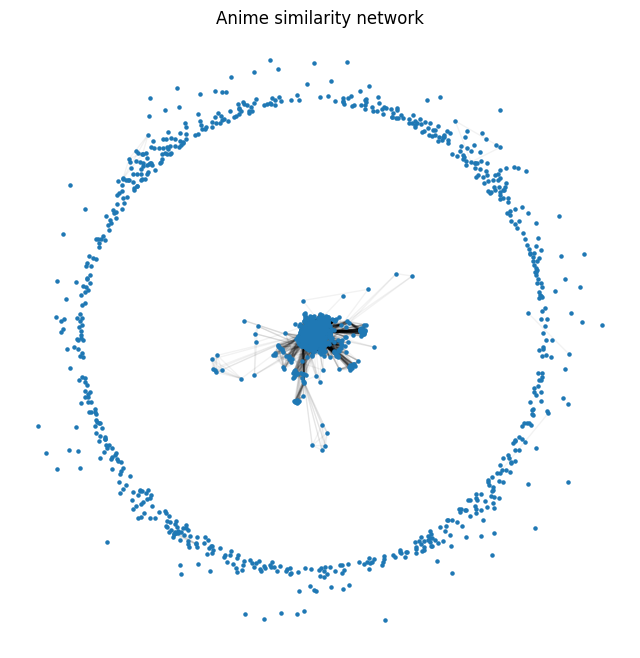

In [27]:
plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=5)
nx.draw_networkx_edges(G, pos, alpha=0.05)
plt.title("Anime similarity network")
plt.axis("off")
plt.show()

## Community analysis

### Louvain algorithm

In [28]:
start = time.time()
partition_louvain = community_louvain.best_partition(G)
time_louvain = time.time() - start

print(f"Louvain")
print(f"Communities: {len(set(partition_louvain.values()))}")
print(f"Execution time: {time_louvain:.3f} s")

Louvain
Communities: 734
Execution time: 8.074 s


### Leiden algorithm

In [29]:
g = ig.Graph.from_networkx(G)
start = time.time()
partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)
time_leiden = time.time() - start
partition_leiden = {}

for community_id, members in enumerate(partition):
    for node in members:
        partition_leiden[g.vs[node]["_nx_name"]] = community_id

print(f"Leiden")
print(f"Communities: {len(partition)}")
print(f"Execution time: {time_leiden:.3f} s")

Leiden
Communities: 733
Execution time: 0.717 s


### Girvan-Newman algorithm

#### Poiché il grafo è molto grande, viene utilizzato un sottografo.

In [30]:
random.seed(42)
sub_nodes = random.sample(list(G.nodes()), 200)
G_small = G.subgraph(sub_nodes).copy()
G_small = G.subgraph(sub_nodes).copy()

In [31]:
start = time.time()
communities = next(girvan_newman(G_small))
time_gn = time.time() - start
partition_gn = {}

for i, community in enumerate(communities):
    for node in community:
        partition_gn[node] = i

print("Girvan-Newman")
print(f"Communities: {len(communities)}")
print(f"Execution time: {time_gn:.3f} s")

Girvan-Newman
Communities: 48
Execution time: 2.952 s


### Summary

In [32]:
results = pd.DataFrame({
    "Algorithm": [
        "Louvain",
        "Leiden",
        "Girvan-Newman"
    ],
    "Communities": [
        len(set(partition_louvain.values())),
        len(set(partition_leiden.values())),
        len(set(partition_gn.values()))
    ],
    "Execution Time (s)": [
        round(time_louvain,3),
        round(time_leiden,3),
        round(time_gn,3)
    ]
})

results

,Algorithm,Communities,Execution Time (s)
0,Louvain,734,8.074
1,Leiden,733,0.717
2,Girvan-Newman,48,2.952


## Evaluate the quality of the communities

In [33]:
nodes = list(G.nodes())

labels_louvain = [partition_louvain[n] for n in nodes]
labels_leiden = [partition_leiden[n] for n in nodes]

In [34]:
nmi = normalized_mutual_info_score(labels_louvain, labels_leiden)
ari = adjusted_rand_score(labels_louvain, labels_leiden)

print("NMI:", nmi)
print("ARI:", ari)

NMI: 0.9698914647585659
ARI: 0.9531163675900407


#### Girvan-Newman was applied only to a reduced graph because of its computational complexity. Therefore, NMI and ARI were computed only between the Louvain and Leiden partitions obtained on the full graph.

### Draw the graph with different colors for the communities

### Louvain

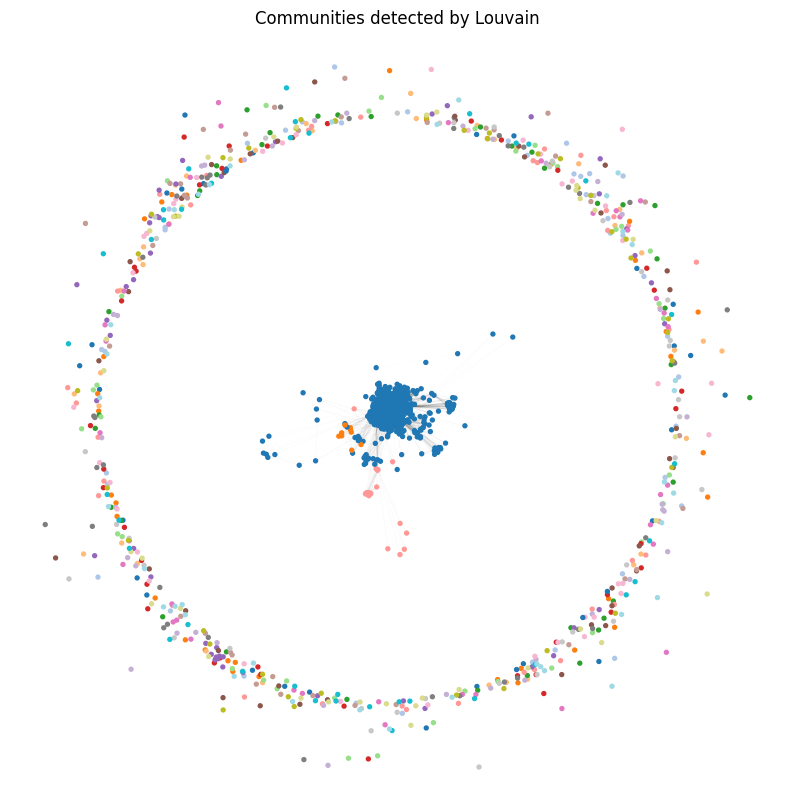

In [35]:
plt.figure(figsize=(10,10))
colors = [partition_louvain[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="tab20", node_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.03, width=0.2)

plt.title("Communities detected by Louvain")
plt.axis("off")
plt.show()

### Leiden

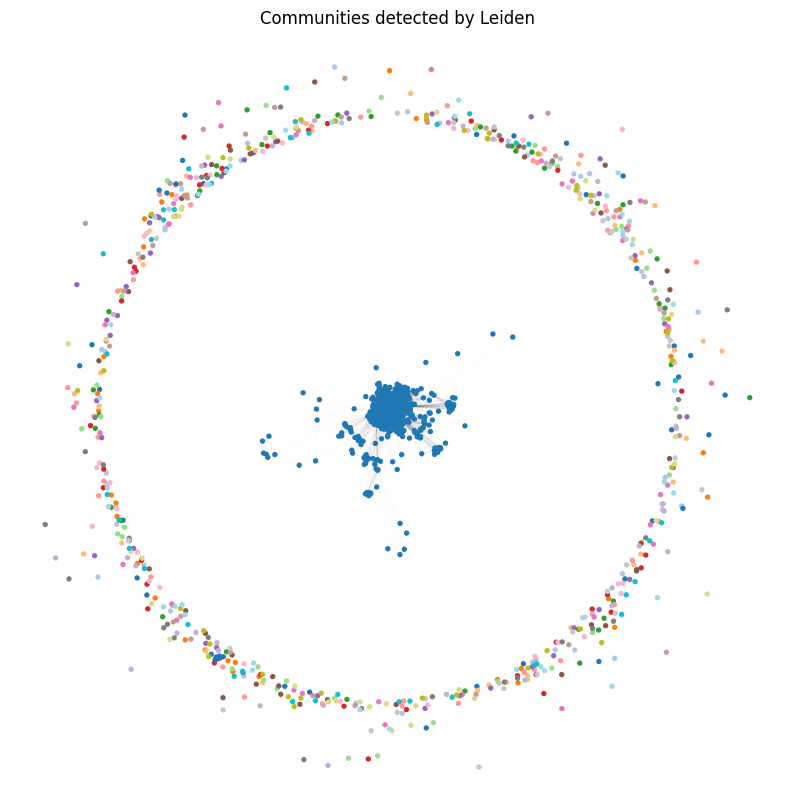

In [36]:
plt.figure(figsize=(10,10))
colors = [partition_leiden[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap="tab20", node_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.03, width=0.2)

plt.title("Communities detected by Leiden")
plt.axis("off")
plt.show()

### Girvan-Newman

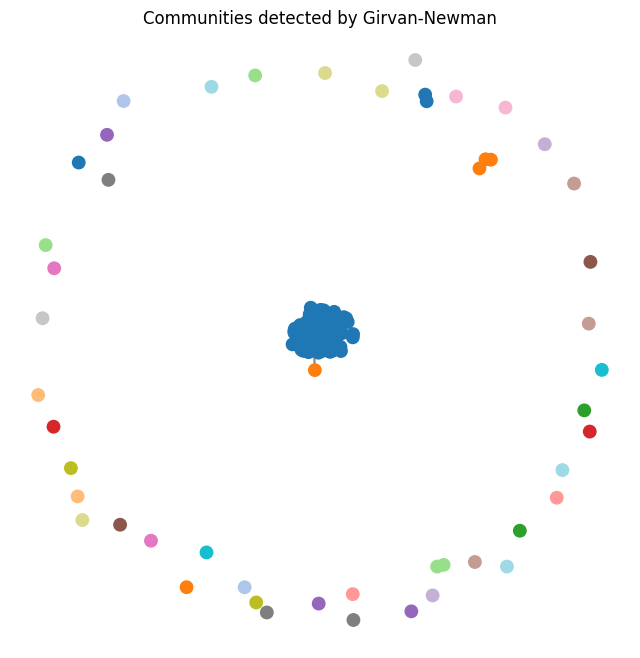

In [37]:
plt.figure(figsize=(8,8))
pos_small = nx.spring_layout(G_small, seed=42)
colors = [partition_gn[n] for n in G_small.nodes()]
nx.draw_networkx_nodes(G_small, pos_small, node_color=colors, cmap="tab20", node_size=80)
nx.draw_networkx_edges(G_small, pos_small, alpha=0.4)

plt.title("Communities detected by Girvan-Newman")
plt.axis("off")
plt.show()